# Cardiotocography — XGBoost Classification via Oracle ML

**Goal:** Predict `CLASS` (10-label fetal heart condition) from CTG features.

**Pipeline:**
1. Pull data from `OML_USER.CARDIOTOCOGRAPHY` (Schema A)
2. PowerTransform + StandardScale
3. Train XGBoost with Bayesian hyperparameter optimisation (Optuna)
4. Convert trained model to ONNX
5. Create Schema B (`CARDIO_MODEL_USER`) in ADB
6. Store ONNX model in Schema B via `DBMS_DATA_MINING.IMPORT_SERMODEL`
7. Score cross-schema from Schema A using SQL `PREDICTION()`

## 1. Imports & DB connection

In [ ]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from dotenv import load_dotenv
load_dotenv(Path.cwd().parent / '.env')

from db.connection import get_connection

conn = get_connection()
print('Connected to Oracle ADB as OML_USER ✓')

## 2. Pull data from Schema A (OML_USER)

In [2]:
query = """
    SELECT LB, AC, FM, UC, DL, DS, DP,
           ASTV, MSTV, ALTV, MLTV,
           WIDTH, MIN, MAX, NMAX, NZEROS,
           MODE_VALUE, MEAN, MEDIAN, VARIANCE, TENDENCY,
           CLASS
    FROM CARDIOTOCOGRAPHY
"""

with conn.cursor() as cur:
    cur.execute(query)
    cols = [d[0] for d in cur.description]
    rows = cur.fetchall()

df = pd.DataFrame(rows, columns=cols)
print(f'Shape: {df.shape}')
df.head()

Shape: (2126, 22)


,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,...,MIN,MAX,NMAX,NZEROS,MODE_VALUE,MEAN,MEDIAN,VARIANCE,TENDENCY,CLASS
0,120,0.000,0.0,0.000,0.000,0.0,0.0,73,0.5,43,...,62,126,2,0,120,137,121,73,1,9
1,132,0.006,0.0,0.006,0.003,0.0,0.0,17,2.1,0,...,68,198,6,1,141,136,140,12,0,6
2,133,0.003,0.0,0.008,0.003,0.0,0.0,16,2.1,0,...,68,198,5,1,141,135,138,13,0,6
3,134,0.003,0.0,0.008,0.003,0.0,0.0,16,2.4,0,...,53,170,11,0,137,134,137,13,1,6
4,132,0.007,0.0,0.008,0.000,0.0,0.0,16,2.4,0,...,53,170,9,0,137,136,138,11,1,2


CLASS distribution:
CLASS
1     384
2     579
3      53
4      81
5      72
6     332
7     252
8     107
9      69
10    197
Name: count, dtype: int64


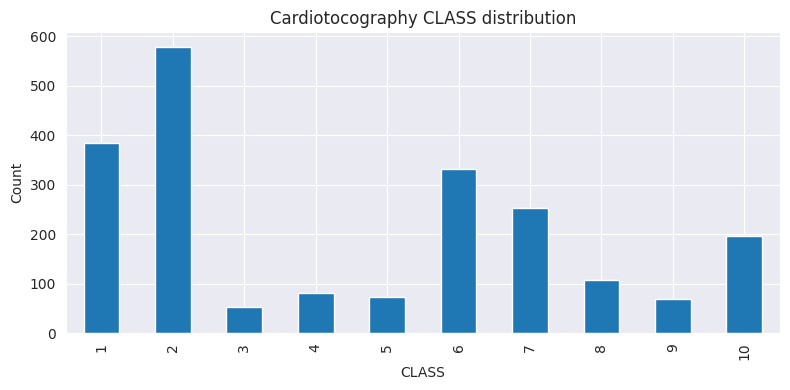

In [3]:
# Class distribution
print('CLASS distribution:')
print(df['CLASS'].value_counts().sort_index())

fig, ax = plt.subplots(figsize=(8, 4))
df['CLASS'].value_counts().sort_index().plot(kind='bar', ax=ax)
ax.set_xlabel('CLASS')
ax.set_ylabel('Count')
ax.set_title('Cardiotocography CLASS distribution')
plt.tight_layout()
plt.show()

## 3. Preprocessing — PowerTransform + StandardScale

In [4]:
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PowerTransformer, StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

FEATURES = [c for c in df.columns if c not in ('CLASS', 'NSP')]
TARGET   = 'CLASS'

X = df[FEATURES].astype(float)
y = df[TARGET].astype(int)

# Oracle CLASS is 1-indexed; XGBoost needs 0-indexed labels
le = LabelEncoder()
y_enc = le.fit_transform(y)  # 1-10 -> 0-9

X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)

print(f'Train: {X_train.shape}  Test: {X_test.shape}')
print(f'Features: {FEATURES}')

Train: (1700, 21)  Test: (426, 21)
Features: ['LB', 'AC', 'FM', 'UC', 'DL', 'DS', 'DP', 'ASTV', 'MSTV', 'ALTV', 'MLTV', 'WIDTH', 'MIN', 'MAX', 'NMAX', 'NZEROS', 'MODE_VALUE', 'MEAN', 'MEDIAN', 'VARIANCE', 'TENDENCY']


In [5]:
preprocessor = Pipeline([
    ('power', PowerTransformer(method='yeo-johnson', standardize=False)),
    ('scaler', StandardScaler()),
])

X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep  = preprocessor.transform(X_test)

print('Preprocessing done ✓')
print(f'Mean after scaling: {X_train_prep.mean(axis=0).mean():.4f} (should be ~0)')
print(f'Std after scaling:  {X_train_prep.std(axis=0).mean():.4f} (should be ~1)')

Preprocessing done ✓
Mean after scaling: 0.0000 (should be ~0)
Std after scaling:  1.0000 (should be ~1)


## 4. Bayesian Hyperparameter Optimisation with Optuna

In [6]:
import optuna
import xgboost as xgb
from sklearn.model_selection import cross_val_score

optuna.logging.set_verbosity(optuna.logging.WARNING)

N_CLASSES = len(le.classes_)

def objective(trial):
    params = {
        'objective':         'multi:softprob',
        'num_class':         N_CLASSES,
        'eval_metric':       'mlogloss',
        'use_label_encoder': False,
        'random_state':      42,
        'n_jobs':            -1,
        'n_estimators':      trial.suggest_int('n_estimators', 100, 800),
        'max_depth':         trial.suggest_int('max_depth', 3, 10),
        'learning_rate':     trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight':  trial.suggest_int('min_child_weight', 1, 10),
        'gamma':             trial.suggest_float('gamma', 0.0, 1.0),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-8, 1.0, log=True),
    }
    model  = xgb.XGBClassifier(**params)
    cv     = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train_prep, y_train, cv=cv, scoring='neg_log_loss', n_jobs=-1)
    return scores.mean()  # maximising neg_log_loss = minimising log_loss

study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f'\nBest CV neg_log_loss: {study.best_value:.4f}  (log_loss = {-study.best_value:.4f})')
print(f'Best params: {study.best_params}')

  0%|          | 0/50 [00:00<?, ?it/s]


Best CV neg_log_loss: -0.3647  (log_loss = 0.3647)
Best params: {'n_estimators': 529, 'max_depth': 6, 'learning_rate': 0.018730010622056547, 'subsample': 0.7842905232144182, 'colsample_bytree': 0.6675211187850174, 'min_child_weight': 2, 'gamma': 0.34881988953649823, 'reg_alpha': 2.873644488410508e-05, 'reg_lambda': 0.0746726009308958}


## 5. Train final model with best hyperparameters

In [7]:
best_params = study.best_params.copy()
best_params.update({
    'objective':         'multi:softprob',
    'num_class':         N_CLASSES,
    'eval_metric':       'mlogloss',
    'use_label_encoder': False,
    'random_state':      42,
    'n_jobs':            -1,
})

final_model = xgb.XGBClassifier(**best_params)
final_model.fit(X_train_prep, y_train)

y_pred = final_model.predict(X_test_prep)
acc    = accuracy_score(y_test, y_pred)
print(f'Test accuracy: {acc:.4f}')
print()
print(classification_report(y_test, y_pred, target_names=[str(c) for c in le.classes_]))

Test accuracy: 0.8873

              precision    recall  f1-score   support

           1       0.84      0.90      0.87        77
           2       0.87      0.93      0.90       116
           3       1.00      0.55      0.71        11
           4       0.92      0.75      0.83        16
           5       1.00      0.36      0.53        14
           6       0.94      0.88      0.91        67
           7       0.94      0.90      0.92        51
           8       0.91      1.00      0.95        21
           9       0.93      1.00      0.97        14
          10       0.83      0.97      0.89        39

    accuracy                           0.89       426
   macro avg       0.92      0.82      0.85       426
weighted avg       0.89      0.89      0.88       426



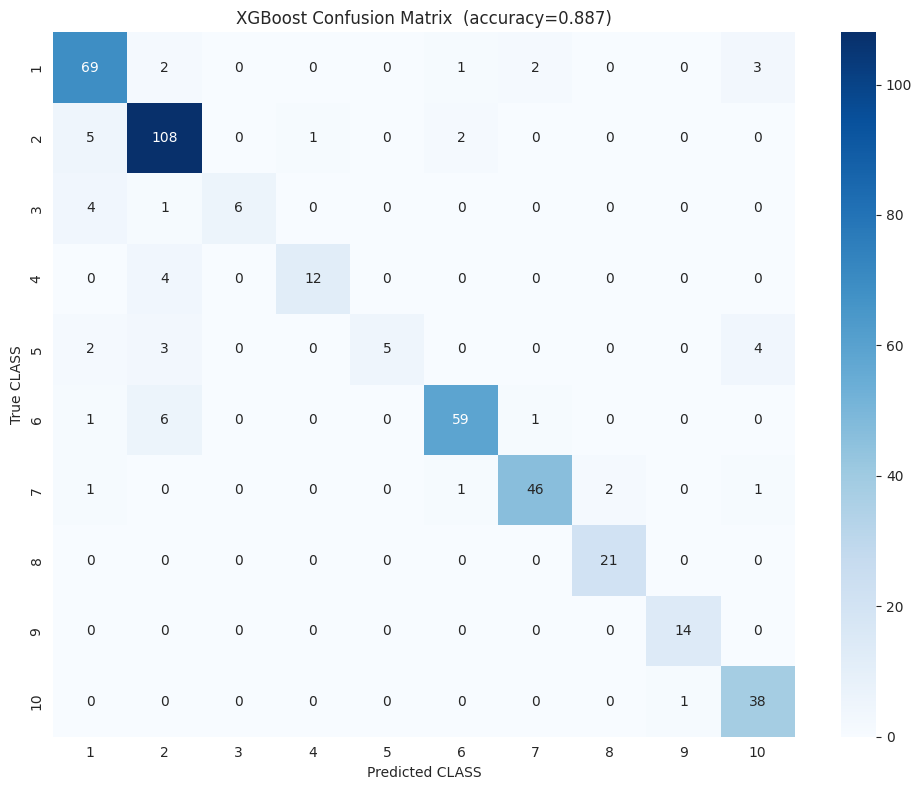

In [8]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
ax.set_xlabel('Predicted CLASS')
ax.set_ylabel('True CLASS')
ax.set_title(f'XGBoost Confusion Matrix  (accuracy={acc:.3f})')
plt.tight_layout()
plt.show()

## 6. Train native Oracle Random Forest in Schema B (CARDIO_MODEL_USER)

**Architecture:**
- Schema A (`OML_USER`) — owns data (`CARDIOTOCOGRAPHY` table)
- Schema B (`CARDIO_MODEL_USER`) — owns the trained ML model

Steps:
1. Connect to Schema B via OCI Vault credentials
2. Grant Schema B `SELECT` on Schema A's table
3. Train `RF_CARDIO_CLASS` in Schema B, referencing `OML_USER.CARDIOTOCOGRAPHY`
4. Grant Schema A `SELECT` (scoring) privilege on the model — enabling cross-schema `PREDICTION()`

In [ ]:
import oracledb
import oci, json, base64

# --- Connect as CARDIO_MODEL_USER (Schema B) via OCI Vault ---
_config = oci.config.from_file()
_secrets = oci.secrets.SecretsClient(_config)

cardio_bundle = _secrets.get_secret_bundle(os.environ['CARDIO_MODEL_USER_SECRET_OCID'])
cardio_creds  = json.loads(base64.b64decode(cardio_bundle.data.secret_bundle_content.content).decode('utf-8'))

CARDIO_USER = 'CARDIO_MODEL_USER'
cardio_conn = oracledb.connect(
    user=cardio_creds['user_name'],
    password=cardio_creds['password'],
    dsn=cardio_creds['dsn'],
)
print(f'Connected as {CARDIO_USER} ✓')

MODEL_NAME = 'RF_CARDIO_CLASS'

# --- Step 1: Drop old model from OML_USER if it exists (cleanup from earlier runs) ---
with conn.cursor() as cur:
    try:
        cur.execute(f"BEGIN DBMS_DATA_MINING.DROP_MODEL('{MODEL_NAME}'); END;")
        conn.commit()
        print(f'Dropped {MODEL_NAME} from OML_USER (cleanup)')
    except Exception:
        pass

# --- Step 2: Grant OML_USER.CARDIOTOCOGRAPHY SELECT to CARDIO_MODEL_USER ---
with conn.cursor() as cur:
    try:
        cur.execute(f"GRANT SELECT ON CARDIOTOCOGRAPHY TO {CARDIO_USER}")
        conn.commit()
        print(f'SELECT on CARDIOTOCOGRAPHY granted to {CARDIO_USER} ✓')
    except Exception as e:
        print(f'Grant note: {e}')

# --- Step 3: Train Oracle RF in Schema B (CARDIO_MODEL_USER) ---
with cardio_conn.cursor() as cur:
    # Drop if exists in CARDIO_MODEL_USER
    try:
        cur.execute(f"BEGIN DBMS_DATA_MINING.DROP_MODEL('{MODEL_NAME}'); END;")
        print(f'Dropped existing {MODEL_NAME} from {CARDIO_USER}')
    except Exception:
        pass

    # Settings table in CARDIO_MODEL_USER
    try:
        cur.execute("DROP TABLE rf_cardio_settings PURGE")
    except Exception:
        pass
    cur.execute("CREATE TABLE rf_cardio_settings (setting_name VARCHAR2(30), setting_value VARCHAR2(4000))")

    settings = [
        ("ALGO_NAME",           "ALGO_RANDOM_FOREST"),
        ("PREP_AUTO",           "ON"),
        ("RFOR_NUM_TREES",      "100"),
        ("RFOR_MTRY",           "7"),        # sqrt(21 features)
        ("RFOR_SAMPLING_RATIO", "0.632"),    # bootstrap ratio
    ]
    cur.executemany("INSERT INTO rf_cardio_settings VALUES (:1, :2)", settings)
    cardio_conn.commit()

    # Train using OML_USER's table — cross-schema data reference
    print(f"Training Oracle Random Forest in {CARDIO_USER}...")
    cur.execute(f"""
        BEGIN
            DBMS_DATA_MINING.CREATE_MODEL(
                model_name          => '{MODEL_NAME}',
                mining_function     => DBMS_DATA_MINING.CLASSIFICATION,
                data_table_name     => 'OML_USER.CARDIOTOCOGRAPHY',
                case_id_column_name => NULL,
                target_column_name  => 'CLASS',
                settings_table_name => 'RF_CARDIO_SETTINGS'
            );
        END;
    """)
    cardio_conn.commit()
    print(f'Model {MODEL_NAME} trained in {CARDIO_USER} ✓')

    # Cleanup settings table
    cur.execute("DROP TABLE rf_cardio_settings PURGE")
    cardio_conn.commit()

# --- Step 4: Grant OML_USER scoring privilege on the model ---
with cardio_conn.cursor() as cur:
    try:
        cur.execute(f"""
            BEGIN
                DBMS_DATA_MINING.GRANT_MODEL_PRIVILEGE(
                    privilege  => 'SELECT',
                    model_name => '{MODEL_NAME}',
                    user_name  => 'OML_USER'
                );
            END;
        """)
        cardio_conn.commit()
        print(f'PREDICTION privilege on {MODEL_NAME} granted to OML_USER ✓')
    except Exception as e:
        print(f'Grant note: {e}')

## 7. Score cross-schema from OML_USER using SQL PREDICTION()

`OML_USER` (Schema A) owns the data and calls `PREDICTION(CARDIO_MODEL_USER.RF_CARDIO_CLASS USING *)`.
The model executes entirely inside the DB — no Python, no network hop.

In [ ]:
# Score from OML_USER — model lives in CARDIO_MODEL_USER (cross-schema PREDICTION)
score_sql = f"""
    SELECT
        CLASS                                                                AS true_class,
        PREDICTION({CARDIO_USER}.{MODEL_NAME} USING *)                     AS predicted_class,
        PREDICTION_PROBABILITY({CARDIO_USER}.{MODEL_NAME} USING *)         AS confidence
    FROM CARDIOTOCOGRAPHY
    FETCH FIRST 20 ROWS ONLY
"""

with conn.cursor() as cur:
    cur.execute(score_sql)
    results = cur.fetchall()

results_df = pd.DataFrame(results, columns=['TRUE_CLASS', 'PREDICTED_CLASS', 'CONFIDENCE'])
results_df['CORRECT'] = results_df['TRUE_CLASS'] == results_df['PREDICTED_CLASS']
print(results_df.to_string(index=False))
print(f'\nAccuracy on sample: {results_df["CORRECT"].mean():.2%}')

In [ ]:
# Verify model exists in CARDIO_MODEL_USER's registry
with cardio_conn.cursor() as cur:
    cur.execute("""
        SELECT model_name, algorithm, mining_function, build_duration
        FROM user_mining_models
        WHERE model_name = 'RF_CARDIO_CLASS'
    """)
    row = cur.fetchone()
    if row:
        print(f'Model: {row[0]}  Algorithm: {row[1]}  Function: {row[2]}  Build time: {row[3]}s')
    else:
        print('Model not found in CARDIO_MODEL_USER')